# TP — Implémentation d'un Mini Réseau de Neurones avec NumPy

**Solution complète.** Ce notebook implémente :
1. Quatre (puis six) fonctions d'activation + un tracé comparatif et une grille de subplots.
2. Un mini réseau de neurones `2 → 3 → 1` entraîné sur **XOR** (forward, MSE, backprop, descente de gradient).
3. (Partie B) Un dataset **XOR bruité**, split train/test, et l'évaluation du modèle :
   matrice de confusion, accuracy / precision / recall / F1, courbe ROC et AUC.

> Toutes les figures sont aussi sauvegardées dans `reports/`.

---
## Partie A — Mini Réseau de Neurones pour XOR
### I — Mise en place
#### I.1. Imports et création du dataset (vecteur `x`)

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Dossier reports/ à la racine du projet (cf. conventions), que le notebook soit
# lancé depuis notebooks/ ou depuis la racine du dépôt.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)

# 600 points régulièrement espacés sur [-3, 3] pour tracer les activations.
x = np.linspace(-3, 3, 600)
print("x.shape =", x.shape, "| x[:3] =", x[:3])

x.shape = (600,) | x[:3] = [-3.         -2.98998331 -2.97996661]


#### I.2. Dictionnaire des fonctions d'activation

- **Relu** : $f(x)=\max(0,x)$
- **Sigmoid** : $f(x)=\dfrac{1}{1+e^{-x}}$
- **Sigmoid_stable** : version par branches (évite l'overflow de `exp` pour $|x|$ grand)
- **Tanh** : $f(x)=\tanh(x)$
- **LeakyRelu** ($a=0.1$) : $f(x)=x$ si $x>0$, sinon $ax$

`d_activations` associe à chaque fonction sa **dérivée** sous la forme `(mode, fonction)`
où `mode="z"` ⇒ la dérivée prend la pré-activation `z`, et `mode="out"` ⇒ elle prend la sortie déjà calculée.

In [2]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_stable(x):
    # Branche selon le signe : on n'évalue jamais exp() sur une grande valeur positive.
    out = np.empty_like(x, dtype=float)
    pos = x >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
    ex = np.exp(x[~pos])
    out[~pos] = ex / (1.0 + ex)
    return out

activations = {
    "Relu":           lambda x: np.maximum(0.0, x),
    "Sigmoid":        sigmoid,
    "Sigmoid_stable": sigmoid_stable,
    "Tanh":           np.tanh,
    "LeakyRelu":      lambda x: np.where(x > 0, x, 0.1 * x),
}

# --- dérivées : (mode, f)  avec mode in {"z", "out"} ---
d_activations = {
    "Relu":           ("z",   lambda z: np.where(z > 0, 1.0, 0.0)),
    "Sigmoid":        ("out", lambda s: s * (1.0 - s)),       # s = sigmoid(z)
    "Sigmoid_stable": ("out", lambda s: s * (1.0 - s)),
    "Tanh":           ("out", lambda a: 1.0 - a ** 2),        # a = tanh(z)
    "LeakyRelu":      ("z",   lambda z: np.where(z > 0, 1.0, 0.1)),
}
print("Fonctions définies :", list(activations))

Fonctions définies : ['Relu', 'Sigmoid', 'Sigmoid_stable', 'Tanh', 'LeakyRelu']


#### I.4. Dictionnaires de style (couleurs et marqueurs)
Une couleur **et** un marqueur distincts par courbe.

In [ ]:
couleurs = {
    "Relu":           "tab:blue",
    "Sigmoid":        "tab:green",
    "Sigmoid_stable": "tab:purple",
    "Tanh":           "tab:red",
    "LeakyRelu":      "tab:orange",
}

markers = {
    "Relu":           "o",   # cercle
    "Sigmoid":        "s",   # carré
    "Sigmoid_stable": "P",   # croix pleine
    "Tanh":           "^",   # triangle haut
    "LeakyRelu":      "D",   # losange
}

### II. Tracé comparatif sur 1 seule figure
Les 4 (+ variante stable) activations sur le **même graphique**.

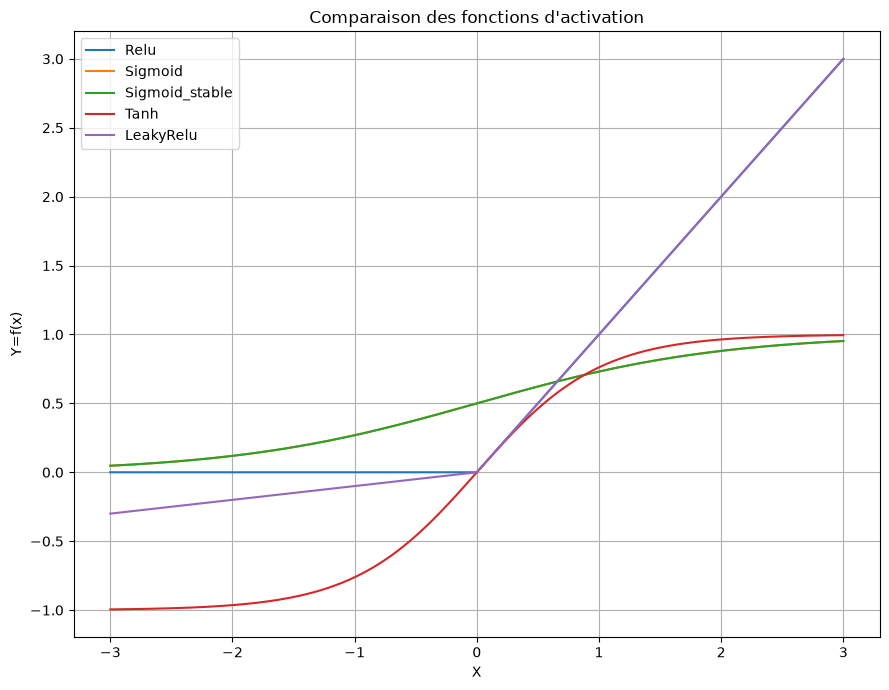

In [5]:
plt.figure(figsize=(9, 7))
for name, f in activations.items():
    style = {}
    if "couleurs" in globals() and name in couleurs:
        style["color"] = couleurs[name]
    if "markers" in globals() and name in markers:
        style["marker"] = markers[name]
        style["markersize"] = 6
        style["markevery"] = 40

    plt.plot(x, f(x), label=name, **style)
plt.title("Comparaison des fonctions d'activation")
plt.xlabel("X")
plt.ylabel("Y=f(x)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / "activations_comparatif.png", dpi=150, bbox_inches="tight")
plt.show()

### III. subplots(2x2) — une fonction par sous-figure

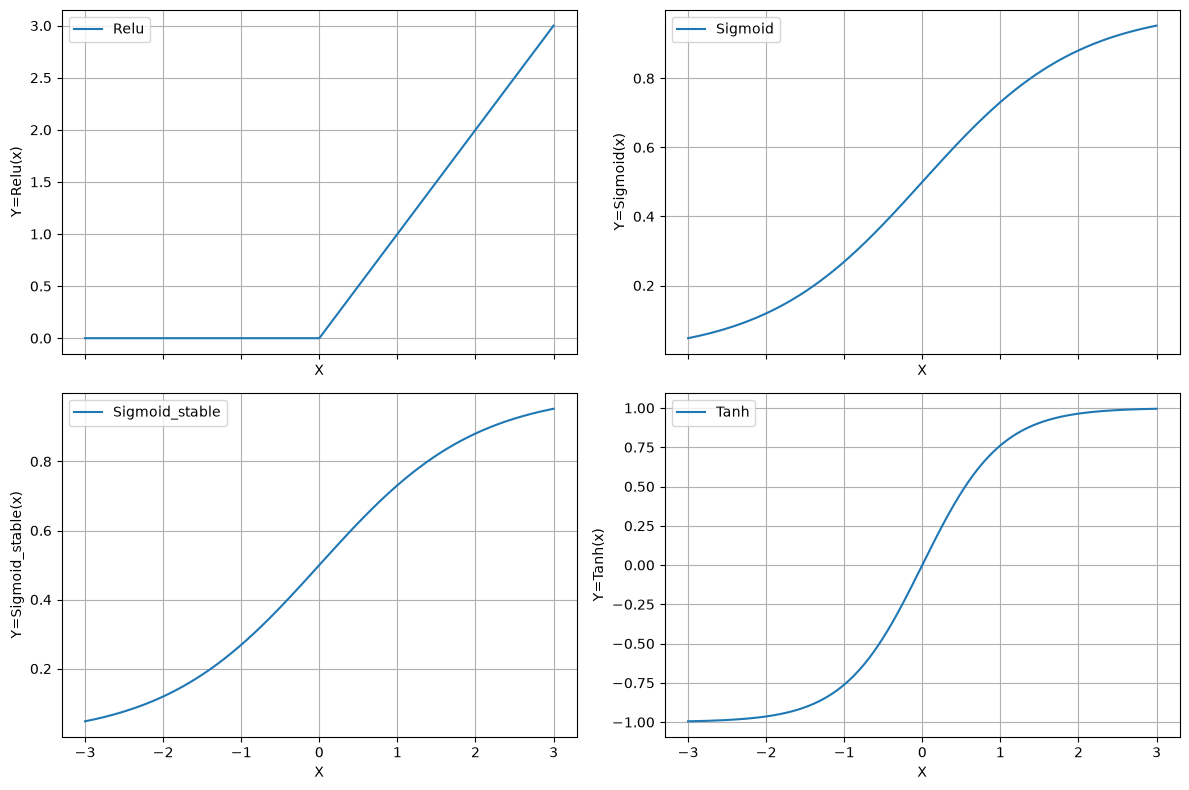

In [6]:
noms_2x2 = ["Relu", "Sigmoid", "Sigmoid_stable", "Tanh"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = axes.ravel()
for ax, name in zip(axes, noms_2x2):
    style = {}
    if "couleurs" in globals() and name in couleurs:
        style["color"] = couleurs[name]
    if "markers" in globals() and name in markers:
        style["marker"] = markers[name]
        style["markersize"] = 6
        style["markevery"] = 40

    ax.plot(x, activations[name](x), label=name, **style)
    ax.set_xlabel("X")
    ax.set_ylabel(f"Y={name}(x)")
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / "activations_subplots_2x2.png", dpi=150, bbox_inches="tight")
plt.show()

### IV. Extension 1 — deux activations supplémentaires
- **Softplus** : $f(x)=\ln(1+e^{x})$  (calculée de façon stable avec `np.logaddexp`)
- **ELU** ($\alpha=1$) : $f(x)=x$ si $x>0$, sinon $\alpha(e^{x}-1)$

> La clé `"Sofplus"` reprend l'orthographe utilisée dans l'énoncé.

In [8]:
ALPHA = 1.0
activations["Sofplus"] = lambda x: np.logaddexp(0.0, x)              # ln(1 + e^x), stable
activations["ELU"]     = lambda x: np.where(x > 0, x, ALPHA * (np.exp(x) - 1.0))

d_activations["Sofplus"] = ("z", lambda z: sigmoid(z))               # softplus' = sigmoid
d_activations["ELU"]     = ("z", lambda z: np.where(z > 0, 1.0, ALPHA * np.exp(z)))

if "couleurs" not in globals():
    couleurs = {}
if "markers" not in globals():
    markers = {}

couleurs["Sofplus"] = "tab:cyan"
couleurs["ELU"]     = "tab:pink"
markers["Sofplus"]  = "+"
markers["ELU"]      = "*"
print("Fonctions définies :", list(activations))

Fonctions définies : ['Relu', 'Sigmoid', 'Sigmoid_stable', 'Tanh', 'LeakyRelu', 'Sofplus', 'ELU']


#### IV.2. Tracé comparatif de toutes les courbes

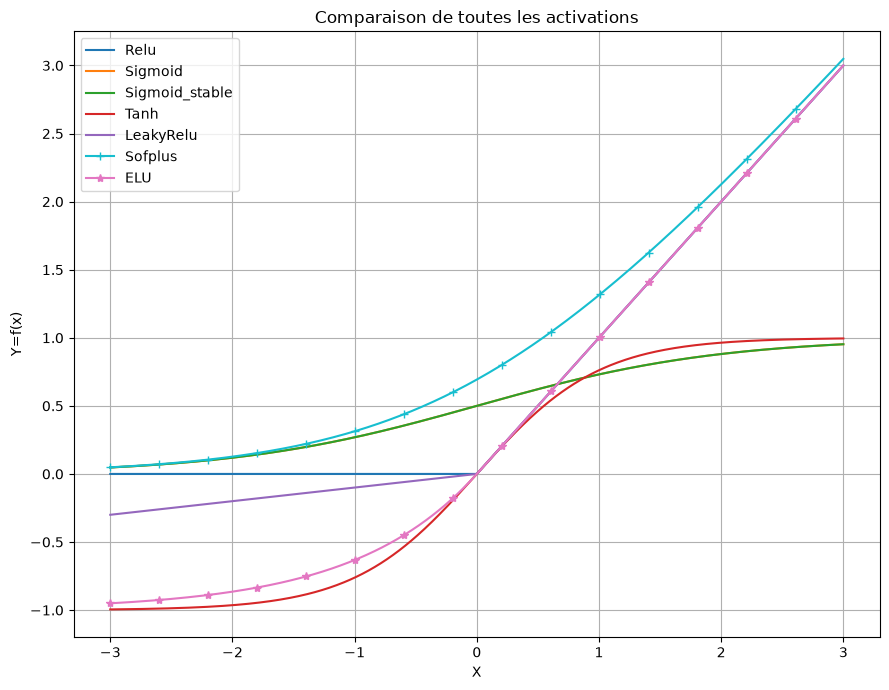

In [10]:
plt.figure(figsize=(9, 7))
for name, f in activations.items():
    style = {}
    if "couleurs" in globals() and name in couleurs:
        style["color"] = couleurs[name]
    if "markers" in globals() and name in markers:
        style["marker"] = markers[name]
        style["markersize"] = 6
        style["markevery"] = 40

    plt.plot(x, f(x), label=name, **style)
plt.title("Comparaison de toutes les activations")
plt.xlabel("X")
plt.ylabel("Y=f(x)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / "activations_comparatif_all.png", dpi=150, bbox_inches="tight")
plt.show()

#### IV.3. Tracé de chaque courbe sur une sous-figure (`sub_tracer`)

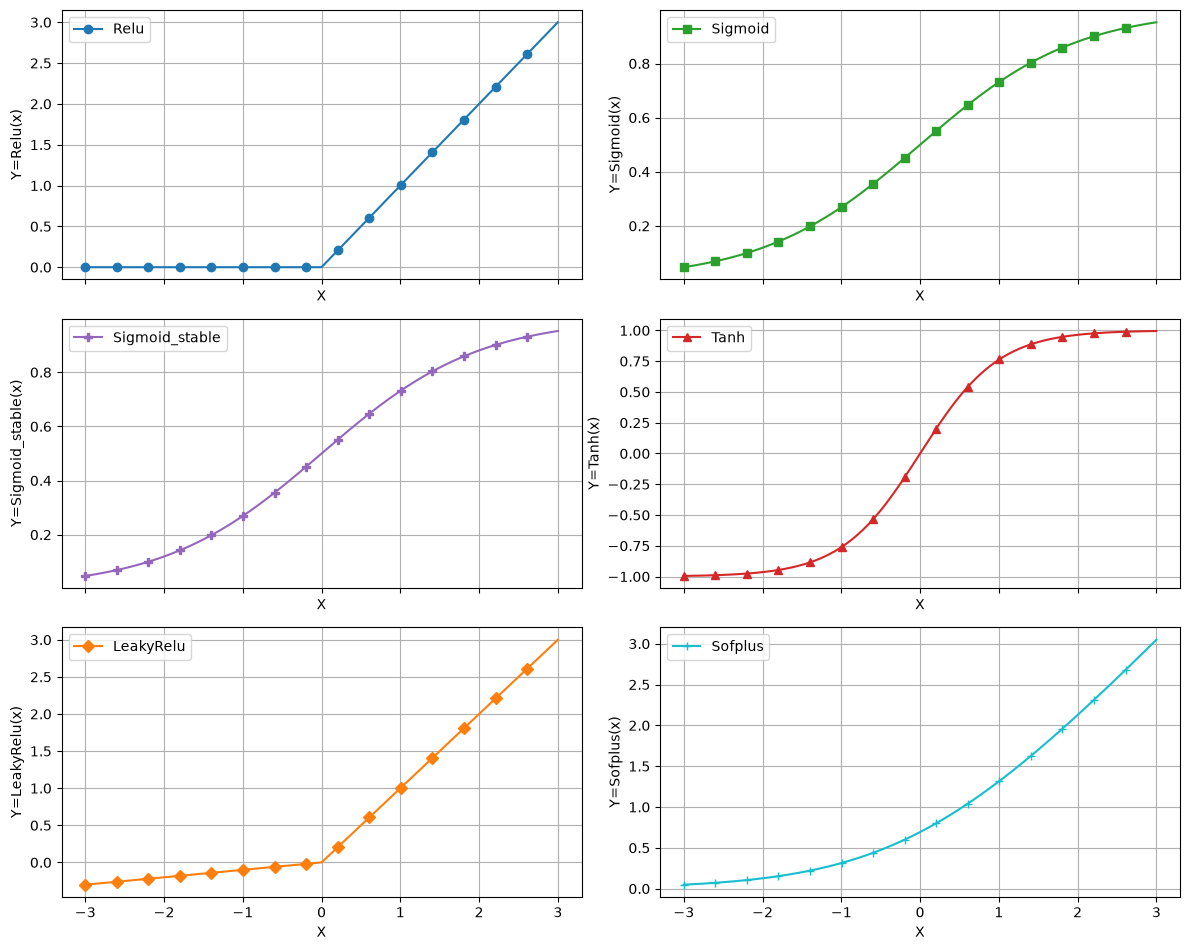

In [12]:
def sub_tracer(rows, cols):
    """Trace chaque activation du dict sur sa propre sous-figure d'une grille rows x cols."""
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.2 * rows), sharex=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, name in zip(axes, activations):
        ax.plot(x, activations[name](x), label=name, color=couleurs[name],
                marker=markers[name], markersize=6, markevery=40)
        ax.set_xlabel("X")
        ax.set_ylabel(f"Y={name}(x)")
        ax.grid(True)
        ax.legend()
    # Masquer les axes restés vides (si rows*cols > nb de fonctions).
    for ax in axes[len(activations):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(REPORTS / "activations_sub_tracer.png", dpi=150, bbox_inches="tight")
    plt.show()

# Ensure style dicts contain all activation names to avoid KeyError (e.g., "Relu")
default_colors = ["tab:blue", "tab:green", "tab:purple", "tab:red", "tab:orange", "tab:cyan", "tab:pink"]
default_markers = ["o", "s", "P", "^", "D", "+", "*"]

if "couleurs" not in globals():
    couleurs = {}
if "markers" not in globals():
    markers = {}

for i, name in enumerate(activations.keys()):
    couleurs.setdefault(name, default_colors[i % len(default_colors)])
    markers.setdefault(name, default_markers[i % len(default_markers)])

sub_tracer(3, 2)

### V. Extension 2 — Mini réseau `2 → 3 → 1` pour apprendre XOR

**XOR** : $y=1$ si les deux entrées diffèrent, sinon $0$.

| x1 | x2 | y |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 1 |
| 1  | 0  | 1 |
| 1  | 1  | 0 |

XOR n'est **pas linéairement séparable** : il faut une couche cachée + une activation non linéaire.

Forward : $Z_1=XW_1+b_1,\;A_1=\tanh(Z_1),\;Z_2=A_1W_2+b_2,\;\hat y=\sigma(Z_2)$.

#### V.2. Préparer le mini-dataset XOR

In [13]:
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)
print("X.shape =", X.shape)   # (4, 2)
print("y.shape =", y.shape)   # (4, 1)

X.shape = (4, 2)
y.shape = (4, 1)


#### V.3. Visualiser les points XOR

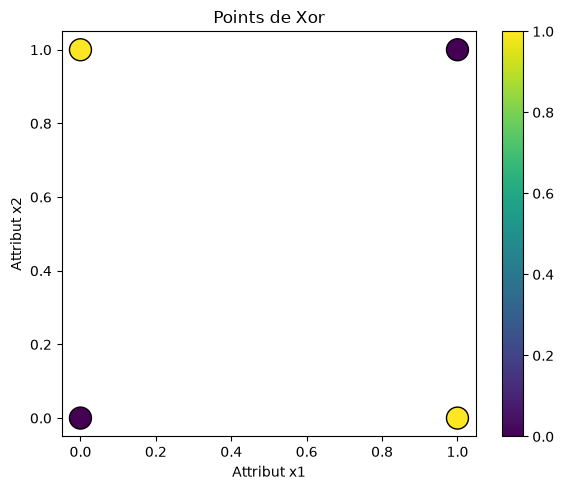

In [14]:
plt.figure(figsize=(6, 5))
sc = plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="viridis", s=250, edgecolors="k")
plt.colorbar(sc)
plt.title("Points de Xor")
plt.xlabel("Attribut x1")
plt.ylabel("Attribut x2")
plt.tight_layout()
plt.savefig(REPORTS / "xor_points.png", dpi=150, bbox_inches="tight")
plt.show()

#### V.4. Initialisation des paramètres (W1, b1, W2, b2)

Shapes : `W1:(2,3)  b1:(1,3)  W2:(3,1)  b2:(1,1)`.

In [15]:
def init_params(input_dim, hidden_dim, output_dim, seed=42, scale=0.5):
    rng = np.random.default_rng(seed)
    W1 = rng.standard_normal((input_dim, hidden_dim)) * scale
    b1 = np.zeros((1, hidden_dim))
    W2 = rng.standard_normal((hidden_dim, output_dim)) * scale
    b2 = np.zeros((1, output_dim))
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_params(2, 3, 1, seed=42, scale=0.5)

# Vérification des shapes : W1:(2,3), b1:(1,3), W2:(3,1), b2:(1,1)
print("W1.shape :", W1.shape, "  b1.shape :", b1.shape)
print("W2.shape :", W2.shape, "  b2.shape :", b2.shape)
print("W1 =\n", W1, "\nb1 =", b1)
print("W2 =\n", W2, "\nb2 =", b2)

W1.shape : (2, 3)   b1.shape : (1, 3)
W2.shape : (3, 1)   b2.shape : (1, 1)
W1 =
 [[ 0.15235854 -0.51999205  0.3752256 ]
 [ 0.47028236 -0.97551759 -0.65108975]] 
b1 = [[0. 0. 0.]]
W2 =
 [[ 0.0639202 ]
 [-0.1581213 ]
 [-0.00840058]] 
b2 = [[0.]]


#### V.5. Choix des activations (une par couche)
- Couche cachée : **tanh**
- Couche de sortie : **sigmoid** (sortie ∈ [0,1] → probabilité)

Dérivées pratiques : $\tanh'(z)=1-a^2$ et $\sigma'(z)=s(1-s)$ (en fonction de la sortie).

In [16]:
act_hid   = activations["Tanh"]
act_out   = activations["Sigmoid_stable"]
d_act_hid = d_activations["Tanh"][1]            # a -> 1 - a^2
d_act_out = d_activations["Sigmoid_stable"][1]  # s -> s(1 - s)

#### V.6. Propagation avant (Forward pass)

In [17]:
def forward(X, W1, b1, W2, b2, act_hid, act_out):
    Z1 = X @ W1 + b1        # produit matriciel + broadcasting du biais
    A1 = act_hid(Z1)
    Z2 = A1 @ W2 + b2
    y_hat = act_out(Z2)
    cache = (X, Z1, A1, Z2, y_hat)
    return y_hat, cache

y_hat, cache = forward(X, W1, b1, W2, b2, act_hid, act_out)
print("y_hat:\n", y_hat)
print("y_hat shape:", y_hat.shape)   # (4, 1)

y_hat:
 [[0.5       ]
 [0.53782778]
 [0.52053485]
 [0.54502776]]
y_hat shape: (4, 1)


#### V.7. Fonction de perte (MSE)
$L=\frac{1}{N}\sum_{i=1}^{N}(\hat y_i-y_i)^2$

In [18]:
def mse(y_hat, y):
    return np.mean((y_hat - y) ** 2)

print("Loss:", mse(y_hat, y))

Loss: 0.2476363134326636


#### V.8 – V.9. Backpropagation + boucle d'entraînement

Gradients (réseau `2→3→1`, sortie sigmoid, cachée tanh) :

$$dY=\tfrac{2}{N}(\hat y-y),\quad dZ_2=dY\odot\hat y(1-\hat y)$$
$$dW_2=A_1^{T}dZ_2,\quad db_2=\textstyle\sum dZ_2$$
$$dA_1=dZ_2W_2^{T},\quad dZ_1=dA_1\odot(1-A_1^2)$$
$$dW_1=X^{T}dZ_1,\quad db_1=\textstyle\sum dZ_1$$

Mise à jour : $W\leftarrow W-\eta\,dW$.

In [19]:
def train(X, y, W1, b1, W2, b2, lr=0.8, epochs=2000,
          f_act_hid=act_hid, f_act_out=act_out, verbose=True):
    # copie pour ne pas modifier les paramètres de l'appelant (ré-exécutions reproductibles)
    W1, b1, W2, b2 = W1.copy(), b1.copy(), W2.copy(), b2.copy()
    losses = []
    N = y.shape[0]
    for epoch in range(epochs):
        # ---------- Forward ----------
        y_hat, (Xc, Z1, A1, Z2, yhc) = forward(X, W1, b1, W2, b2, f_act_hid, f_act_out)

        # ---------- Loss ----------
        L = mse(y_hat, y)
        losses.append(L)

        # ---------- Backprop ----------
        dY  = 2.0 * (y_hat - y) / N           # (N,1)
        dZ2 = dY * d_act_out(y_hat)           # sigmoid' = y_hat(1-y_hat)  -> (N,1)
        dW2 = A1.T @ dZ2                       # (3,N)@(N,1) -> (3,1)
        db2 = np.sum(dZ2, axis=0, keepdims=True)   # (1,1)

        dA1 = dZ2 @ W2.T                       # (N,1)@(1,3) -> (N,3)
        dZ1 = dA1 * d_act_hid(A1)              # tanh' = 1 - A1^2 -> (N,3)
        dW1 = X.T @ dZ1                        # (2,N)@(N,3) -> (2,3)
        db1 = np.sum(dZ1, axis=0, keepdims=True)   # (1,3)

        # ---------- Update ----------
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        if verbose and epoch % 400 == 0:
            print(f"epoch={epoch:4d}  loss={L:.6f}")
    return W1, b1, W2, b2, losses


W1t, b1t, W2t, b2t, losses = train(X, y, W1, b1, W2, b2, lr=0.8, epochs=4000)
y_pred, _ = forward(X, W1t, b1t, W2t, b2t, act_hid, act_out)
print("Probas:\n", y_pred)
print("Classes:\n", (y_pred >= 0.5).astype(int))

epoch=   0  loss=0.247636
epoch= 400  loss=0.006421
epoch= 800  loss=0.001876
epoch=1200  loss=0.001047
epoch=1600  loss=0.000716
epoch=2000  loss=0.000541
epoch=2400  loss=0.000433
epoch=2800  loss=0.000360
epoch=3200  loss=0.000308
epoch=3600  loss=0.000269
Probas:
 [[0.0149577 ]
 [0.98121036]
 [0.99167181]
 [0.01756387]]
Classes:
 [[0]
 [1]
 [1]
 [0]]


#### V.10. Courbe de convergence de la loss

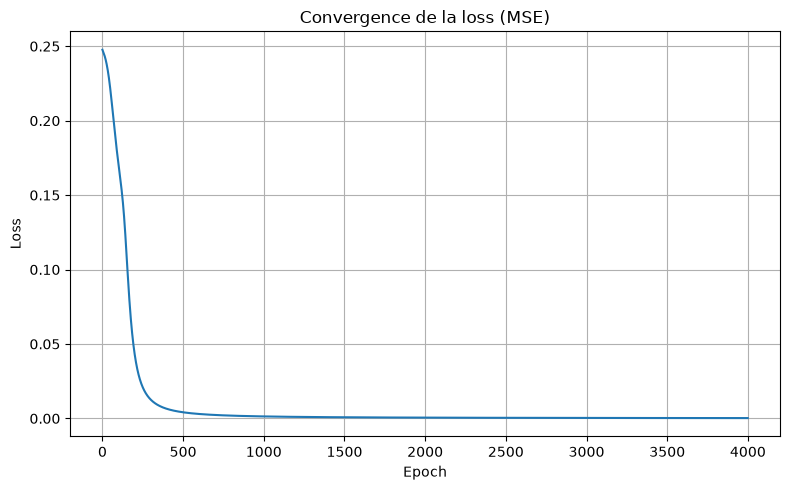

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.title("Convergence de la loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig(REPORTS / "convergence_loss.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Partie B — Dataset bruité + évaluation du modèle

On génère un **XOR bruité**, on sépare en train/test, on entraîne le réseau, puis on
évalue : matrice de confusion, accuracy / precision / recall / F1, courbe ROC et AUC.

### I — Génération d'un dataset XOR bruité
Chaque coin du XOR est dupliqué `n` fois, perturbé par un bruit gaussien
$X_{bruit}=X+\epsilon,\;\epsilon\sim\mathcal N(0,\sigma^2)$, et une fraction `flip` des labels est inversée.

In [21]:
def make_noisy_xor(n=10, noise=0.08, flip=0.05, seed=0):
    """Génère un dataset XOR bruité (4*n exemples)."""
    rng = np.random.default_rng(seed)

    # points XOR de base
    coins  = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
    labels = np.array([[0], [1], [1], [0]], dtype=float)

    # duplication des points
    X = np.repeat(coins, n, axis=0)
    y = np.repeat(labels, n, axis=0)

    # ajout de bruit gaussien (0 = centre ; noise = écart-type)
    X = X + rng.normal(0.0, noise, X.shape)

    # inversion aléatoire de certains labels
    mask = rng.random(len(y)) < flip
    y[mask] = 1.0 - y[mask]
    return X, y

#### I.3. Génération du dataset

In [22]:
X, y = make_noisy_xor(n=100, noise=0.05, flip=0.04)
print("X.shape =", X.shape)
print(np.hstack([X, y])[:6])   # aperçu des 6 premières lignes

X.shape = (400, 2)
[[ 0.00628651 -0.00660524  0.        ]
 [ 0.03202113  0.00524501  0.        ]
 [-0.02678347  0.01807975  0.        ]
 [ 0.0652      0.04735405  0.        ]
 [-0.03518676 -0.06327107  0.        ]
 [-0.03116372  0.0020663   0.        ]]


### II — Séparation Train / Test
On mélange les indices puis on coupe selon `test_ratio`.

In [23]:
def split_dataset(X, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    N = len(X)
    indices = np.arange(N)
    rng.shuffle(indices)
    cut = int((1 - test_ratio) * N)
    train_idx = indices[:cut]
    test_idx  = indices[cut:]
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_dataset(X, y)
print("Train size :", X_train.shape)
print("Test  size :", X_test.shape)

Train size : (320, 2)
Test  size : (80, 2)


### III — Entraînement du modèle
On réutilise `train()`. On repart de paramètres **fraîchement initialisés**.

> L'énoncé suggère `epochs=100000` ; `20000` suffisent largement à converger ici
> (et exécutent le notebook plus vite). Augmentez si vous voulez reproduire l'énoncé.

In [24]:
W1, b1, W2, b2 = init_params(2, 3, 1, seed=1, scale=0.5)
W1, b1, W2, b2, losses = train(
    X_train, y_train, W1, b1, W2, b2,
    lr=0.5, epochs=20000, verbose=False,
)
print("Loss finale (train) :", losses[-1])

Loss finale (train) : 0.038502079054245374


#### III.2. Prédictions du modèle (conversion proba → classe)
$\hat y=1$ si $p\ge 0.5$, sinon $0$.

In [25]:
y_score, _ = forward(X_test, W1, b1, W2, b2, act_hid, act_out)
threshold = 0.5
y_pred_test = (y_score >= threshold).astype(int)
print("Classes (5 premières):\n", y_pred_test[:5, :])

Classes (5 premières):
 [[0]
 [1]
 [0]
 [1]
 [1]]


### IV. Matrice de confusion : TP, TN, FP, FN
Classe positive = 1.

In [26]:
def confusion_matrix(y_true, y_pred):
    yt = np.asarray(y_true).ravel()
    yp = np.asarray(y_pred).ravel()
    TP = int(np.sum((yt == 1) & (yp == 1)))
    TN = int(np.sum((yt == 0) & (yp == 0)))
    FP = int(np.sum((yt == 0) & (yp == 1)))
    FN = int(np.sum((yt == 1) & (yp == 0)))
    return TP, TN, FP, FN

TP, TN, FP, FN = confusion_matrix(y_test, y_pred_test)
print("TP :", TP)
print("TN :", TN)
print("FP :", FP)
print("FN :", FN)

TP : 32
TN : 43
FP : 3
FN : 2


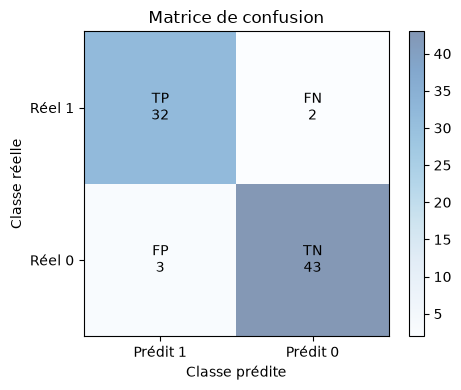

In [27]:
# matrice de confusion : lignes = Réel 1/0, colonnes = Prédit 1/0
cm = np.array([[TP, FN],
               [FP, TN]])
cm_txt = np.array([[f"TP\n{TP}", f"FN\n{FN}"],
                   [f"FP\n{FP}", f"TN\n{TN}"]])

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues", alpha=0.5)
plt.title("Matrice de confusion")
plt.colorbar()
plt.xticks([0, 1], ["Prédit 1", "Prédit 0"])
plt.yticks([0, 1], ["Réel 1", "Réel 0"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm_txt[i, j], ha="center", va="center")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.savefig(REPORTS / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### V — Métriques de classification
$$\text{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN},\quad
\text{Precision}=\frac{TP}{TP+FP},\quad
\text{Recall}=\frac{TP}{TP+FN},\quad
F1=\frac{2\cdot P\cdot R}{P+R}$$

In [28]:
def classification_metrics(TP, TN, FP, FN):
    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall    = TP / (TP + FN) if (TP + FN) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return accuracy, precision, recall, f1

accuracy, precision, recall, f1 = classification_metrics(TP, TN, FP, FN)
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1        :", f1)

Accuracy  : 0.9375
Precision : 0.9142857142857143
Recall    : 0.9411764705882353
F1        : 0.9275362318840579


### VI. Courbe ROC
Pour chaque seuil $t$ : $\hat y=1$ si $p\ge t$. On calcule
$TPR=\frac{TP}{TP+FN}$ et $FPR=\frac{FP}{FP+TN}$.

In [29]:
def roc_curve(y_true, y_score):
    thresholds = np.linspace(1, 0, 200)
    TPR, FPR = [], []
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
        TPR.append(TP / (TP + FN) if (TP + FN) else 0.0)
        FPR.append(FP / (FP + TN) if (FP + TN) else 0.0)
    return np.array(FPR), np.array(TPR)

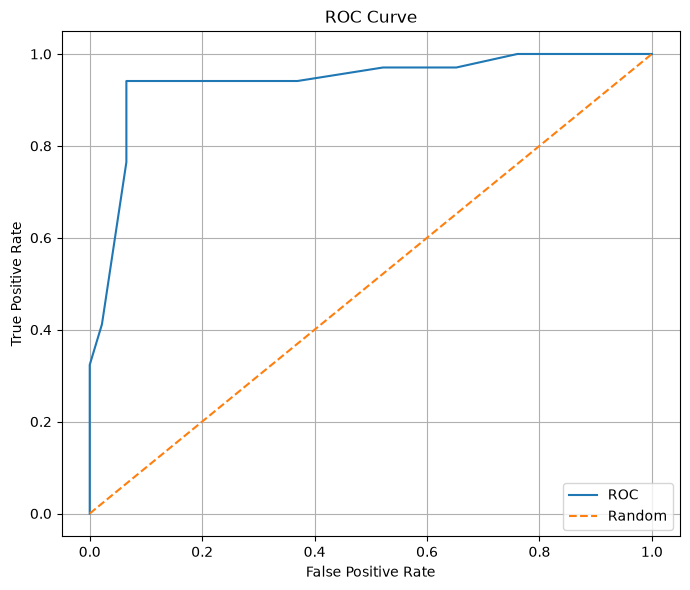

In [30]:
FPR, TPR = roc_curve(y_test, y_score)

plt.figure(figsize=(7, 6))
plt.plot(FPR, TPR, label="ROC")
plt.plot([0, 1], [0, 1], "--", label="Random")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

#### VI.4. Calcul de l'AUC
Aire sous la courbe ROC. AUC ≈ 1 : excellent ; ≈ 0.5 : aléatoire.

In [31]:
import scipy.integrate as integr

auc = integr.trapezoid(TPR, FPR)
print("AUC =", auc)

AUC = 0.9382992327365728
